# Illinois Pension Reform — Descriptive Statistics from MORG
## Raw CPS Merged Outgoing Rotation Groups, 2008–2017

Produces all descriptive tables and figures for Section 5 of the paper directly
from the annual MORG CSV files (`morg08.csv` – `morg17.csv`).

**What this notebook produces:**
- Table 1: Weighted sample characteristics by state × sector (pre-reform pooled)
- Table 2: Pre vs post comparison for Illinois
- Table 3: Public vs private worker characteristics, all states
- Figure 1: Age distribution — public vs private, IL vs comparison states
- Figure 2: Female share over time by state and sector
- Figure 3: Mean weekly earnings over time by state and sector
- Figure 4: Union coverage over time by state
- Figure 5: Education composition over time (Illinois)
- Figure 6: Mean age over time by state (public sector)
- Figure 7: Race/ethnicity composition (Illinois)
- Figure 8: Public-sector employment share over time by state


In [1]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
from pathlib import Path

# Directory containing morg08.csv … morg17.csv
DATA_DIR   = Path.home() / "Documents" / "pdi_pensions" / "data" / "csv"
OUTPUT_DIR = Path("morg_descriptive_output")
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS      = list(range(2008, 2018))        # 2008–2017
REFORM_YEAR = 2011                          # Tier 2 enacted Jan 2011

# Comparison states (FIPS). IL=17. NY excluded from retention; PA from recruitment.
# For descriptive purposes we include all of them and note exclusions in text.
STATES_OF_INTEREST = {
    17: 'Illinois',
    18: 'Indiana',
    36: 'New York',
    42: 'Pennsylvania',
    26: 'Michigan',
    55: 'Wisconsin',
    39: 'Ohio',
}

# class94: class of worker
# 1=private, 2=federal govt, 3=state govt, 4=local govt, 5=self-emp inc, 6=self-emp not inc
STATE_LOCAL_CLASSES = {3, 4}      # state and local government
PRIVATE_CLASSES     = {1}         # private sector only
GOVT_CLASSES        = {2, 3, 4}   # all government

# Colors
STATE_COLORS = {
    17: '#1a6faf',   # IL — blue (treated)
    18: '#27ae60',   # IN — green
    36: '#e74c3c',   # NY — red
    42: '#9b59b6',   # PA — purple
    26: '#f39c12',   # MI — amber
    55: '#16a085',   # WI — teal
    39: '#e67e22',   # OH — orange
}

# Education groups (grade92)
EDUC_GROUPS = {
    'HS or less':    list(range(0, 40)),
    'Some college':  [40, 41],
    "Bachelor's":    [43],
    'Graduate+':     [44, 45, 46],
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

def save(fig, name):
    for ext in ['pdf', 'png']:
        fig.savefig(OUTPUT_DIR / f"{name}.{ext}")
    print(f"  Saved {name}")

print("Configuration set.")
print(f"DATA_DIR: {DATA_DIR}")
files = sorted(DATA_DIR.glob("morg*.csv")) if DATA_DIR.exists() else []
print(f"MORG files found: {len(files)}")
for f in files:
    print(f"  {f.name}")


Configuration set.
DATA_DIR: /Users/vedikabaradwaj/Documents/pdi_pensions/data/csv
MORG files found: 10
  morg08.csv
  morg09.csv
  morg10.csv
  morg11.csv
  morg12.csv
  morg13.csv
  morg14.csv
  morg15.csv
  morg16.csv
  morg17.csv


In [2]:
# ── PEEK AT COLUMNS — run this first to verify variable names ─────────────────
import pandas as pd
from pathlib import Path

# Read just 5 rows to see column names
sample_file = DATA_DIR / "morg08.csv"
if sample_file.exists():
    peek = pd.read_csv(sample_file, nrows=5, low_memory=False)
    peek.columns = peek.columns.str.lower().str.strip()
    print("Columns in morg08.csv:")
    for i, c in enumerate(peek.columns):
        print(f"  {i:3d}  {c}")
    print(f"\nShape of first 5 rows: {peek.shape}")
    print("\nSample values:")
    key_cols = [c for c in ['stfips','statefip','age','sex','race','prdtrace',
                             'class94','classwkr','ind02','earnwke','earnwt',
                             'finalwgt','grade92','unionmme','unioncov','ethnic',
                             'lfstat','uhourse'] if c in peek.columns]
    print(peek[key_cols].to_string())
else:
    print(f"File not found: {sample_file}")
    print("Please update DATA_DIR in the configuration cell.")


Columns in morg08.csv:
    0  hhid
    1  intmonth
    2  hurespli
    3  hrhtype
    4  minsamp
    5  hrlonglk
    6  hrsample
    7  hrhhid2
    8  serial
    9  hhnum
   10  state
   11  stfips
   12  cbsafips
   13  county
   14  centcity
   15  smsastat
   16  icntcity
   17  smsa04
   18  relref95
   19  age
   20  spouse
   21  sex
   22  grade92
   23  race
   24  ethnic
   25  lineno
   26  famnum
   27  pfamrel
   28  marital
   29  prpertyp
   30  penatvty
   31  pemntvty
   32  pefntvty
   33  prcitshp
   34  prcitflg
   35  peinusyr
   36  selfproxy
   37  lfsr94
   38  absent94
   39  uhourse
   40  reason94
   41  hourslw
   42  laydur
   43  dwrsn
   44  why3594
   45  prunedur
   46  untype
   47  ftpt94
   48  class94
   49  agri
   50  eligible
   51  otc
   52  ernpdh2
   53  paidhre
   54  earnhre
   55  earnwke
   56  unionmme
   57  unioncov
   58  schenr
   59  studftpt
   60  schlvl
   61  earnwt
   62  weight
   63  chldpres
   64  ownchild
   65  i25d
   66 

In [3]:
# ── COLUMN MAPPING — adjust if your column names differ ───────────────────────
# After running the peek cell above, update any names that differ from the defaults.

COL = {
    'state':    'stfips',       # State FIPS — try 'statefip' if stfips missing
    'age':      'age',
    'sex':      'sex',          # 1=male, 2=female
    'race':     'race',     # post-2003 detailed race; fall back to 'race'
    'ethnic':   'ethnic',       # Hispanic origin
    'educ':     'grade92',      # educational attainment
    'class':    'class94',      # class of worker
    'ind':      'ind02',        # industry
    'earnwke':  'earnwke',      # usual weekly earnings (outgoing rotation only)
    'earnwt':   'earnwt',       # earnings weight
    'finalwgt': 'weight',     # demographic weight
    'union_mem':'unionmme',     # union member (1=yes, 2=no)
    'union_cov':'unioncov',     # union coverage (1=yes, 2=no)
    'lfstat':   'lfstat',       # labor force status
    'uhourse':  'uhourse',      # usual hours per week
}

# If your files use different names, edit the values above, e.g.:
#   COL['state'] = 'statefip'
#   COL['class'] = 'classwkr'
#   COL['race']  = 'race'

print("Column mapping configured.")
print("Run the peek cell first if you need to verify column names.")


Column mapping configured.
Run the peek cell first if you need to verify column names.


In [4]:
# ── LOAD ALL MORG FILES ────────────────────────────────────────────────────────
# Only keeps columns we need and filters to states of interest.
# Uses chunked reading to handle large files.

KEEP_COLS_CANDIDATES = list(set(COL.values()))

def load_morg_year(year, data_dir, states):
    """Load one MORG year file, keep relevant states and columns."""
    yy   = str(year)[-2:]
    path = data_dir / f"morg{yy}.csv"
    if not path.exists():
        print(f"  ✗ Not found: {path.name}")
        return None

    # Read in chunks to handle large files
    chunks = []
    for chunk in pd.read_csv(path, low_memory=False, chunksize=50_000):
        chunk.columns = chunk.columns.str.lower().str.strip()

        # State column — try both common names
        state_col = COL['state'] if COL['state'] in chunk.columns else                     ('statefip' if 'statefip' in chunk.columns else None)
        if state_col is None:
            print(f"  ✗ No state column found in {path.name}")
            return None

        # Filter to states of interest
        state_vals = pd.to_numeric(chunk[state_col], errors='coerce')
        chunk = chunk[state_vals.isin(states)].copy()
        if len(chunk) == 0:
            continue

        chunks.append(chunk)

    if not chunks:
        print(f"  ✗ No matching rows in {path.name}")
        return None

    df = pd.concat(chunks, ignore_index=True)
    df['year'] = year
    print(f"  ✓ {path.name}: {len(df):,} rows (filtered to {len(states)} states)")
    return df


print("Loading MORG files...")
frames = []
for yr in YEARS:
    df = load_morg_year(yr, DATA_DIR, set(STATES_OF_INTEREST.keys()))
    if df is not None:
        frames.append(df)

morg = pd.concat(frames, ignore_index=True)
morg.columns = morg.columns.str.lower().str.strip()
print(f"\nTotal rows loaded: {len(morg):,}")
print(f"Years:  {sorted(morg['year'].unique())}")


Loading MORG files...
  ✓ morg08.csv: 60,704 rows (filtered to 7 states)
  ✓ morg09.csv: 61,662 rows (filtered to 7 states)
  ✓ morg10.csv: 61,634 rows (filtered to 7 states)
  ✓ morg11.csv: 60,775 rows (filtered to 7 states)
  ✓ morg12.csv: 60,282 rows (filtered to 7 states)
  ✓ morg13.csv: 59,831 rows (filtered to 7 states)
  ✓ morg14.csv: 59,437 rows (filtered to 7 states)
  ✓ morg15.csv: 56,421 rows (filtered to 7 states)
  ✓ morg16.csv: 56,247 rows (filtered to 7 states)
  ✓ morg17.csv: 54,781 rows (filtered to 7 states)

Total rows loaded: 591,774
Years:  [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


In [5]:
# ── HARMONISE VARIABLES ────────────────────────────────────────────────────────
def col(name):
    """Look up actual column name, return NaN series if missing."""
    c = COL.get(name, name)
    return morg[c] if c in morg.columns else pd.Series(np.nan, index=morg.index)

# State FIPS
state_col = COL['state'] if COL['state'] in morg.columns else 'statefip'
morg['stfips'] = pd.to_numeric(morg[state_col], errors='coerce').astype('Int64')

# Treated state indicator
morg['illinois'] = (morg['stfips'] == 17).astype(int)

# Post-reform indicator
morg['post'] = (morg['year'] >= REFORM_YEAR).astype(int)

# Demographics
morg['age']    = pd.to_numeric(col('age'),    errors='coerce')
morg['female'] = (pd.to_numeric(col('sex'),   errors='coerce') == 2).astype(float)

# Race — auto-detect whether prdtrace (post-2003, detailed) or race (pre-2003, 3-cat) is present
_race_col = 'prdtrace' if 'prdtrace' in morg.columns else COL['race']
morg['race_raw'] = pd.to_numeric(morg[_race_col], errors='coerce')
_race_max = morg['race_raw'].max()
print(f"  Race column: '{_race_col}', max value: {_race_max:.0f}")

if _race_max <= 3:
    # Pre-2003 coding: 1=White, 2=Black, 3=Other (no separate Asian)
    print("  Detected pre-2003 race coding (3 categories)")
    morg['white']      = (morg['race_raw'] == 1).astype(float)
    morg['black']      = (morg['race_raw'] == 2).astype(float)
    morg['asian']      = pd.Series(np.nan, index=morg.index)   # not available
    morg['other_race'] = (morg['race_raw'] == 3).astype(float)
else:
    # Post-2003 prdtrace: 1=White, 2=Black, 4=Asian, others=multiracial
    print("  Detected post-2003 race coding (prdtrace, detailed)")
    morg['white']      = (morg['race_raw'] == 1).astype(float)
    morg['black']      = (morg['race_raw'] == 2).astype(float)
    morg['asian']      = (morg['race_raw'] == 4).astype(float)
    morg['other_race'] = (~morg['race_raw'].isin([1,2,4]) & morg['race_raw'].notna()).astype(float)

# Hispanic
morg['hispanic'] = pd.to_numeric(col('ethnic'), errors='coerce')
# prorigin: values 2–7 are Hispanic categories; 1 and 8+ are non-Hispanic
morg['is_hispanic'] = morg['hispanic'].between(2, 7, inclusive='both').astype(float)

# Education
morg['grade92'] = pd.to_numeric(col('educ'), errors='coerce')
morg['educ_hs_or_less']   = morg['grade92'].lt(40).astype(float)
morg['educ_some_college']  = morg['grade92'].isin([40, 41]).astype(float)
morg['educ_bachelor']      = (morg['grade92'] == 43).astype(float)
morg['educ_graduate']      = morg['grade92'].isin([44, 45, 46]).astype(float)
morg['educ_ba_plus']       = (morg['grade92'] >= 43).astype(float)

# Class of worker → sector
morg['class94_raw'] = pd.to_numeric(col('class'), errors='coerce')
morg['pub_sl']      = morg['class94_raw'].isin(STATE_LOCAL_CLASSES).astype(float)
morg['pub_fed']     = (morg['class94_raw'] == 2).astype(float)
morg['pub_any']     = morg['class94_raw'].isin(GOVT_CLASSES).astype(float)
morg['private']     = morg['class94_raw'].isin(PRIVATE_CLASSES).astype(float)
morg['employed']    = morg['class94_raw'].notna() & morg['class94_raw'].gt(0)

# Earnings — only valid for outgoing rotation members
morg['earnwke'] = pd.to_numeric(col('earnwke'), errors='coerce')
morg['earnwke'] = morg['earnwke'].where(morg['earnwke'] > 0)  # 0 = not in outgoing rotation
morg['earnwt']  = pd.to_numeric(col('earnwt'),  errors='coerce').fillna(0)
morg['log_earn']= np.where(morg['earnwke'].notna(), np.log(morg['earnwke']), np.nan)

# Demographic weight (for population counts and non-earnings stats)
# Weight — try COL['finalwgt'] first, then common fallbacks
_wt_col = next((c for c in [COL['finalwgt'], 'weight', 'finalwgt', 'wtfinl']
                if c in morg.columns), None)
if _wt_col:
    morg['wt'] = pd.to_numeric(morg[_wt_col], errors='coerce').fillna(0)
    print(f"  Using weight column: '{_wt_col}'")
else:
    raise ValueError("No weight column found. Check COL['finalwgt'] mapping.")

# Union
morg['union_cov'] = (pd.to_numeric(col('union_cov'), errors='coerce') == 1).astype(float)
morg['union_mem'] = (pd.to_numeric(col('union_mem'), errors='coerce') == 1).astype(float)

# Labor force participation
if COL['lfstat'] in morg.columns:
    morg['lfstat_raw'] = pd.to_numeric(morg[COL['lfstat']], errors='coerce')
    morg['employed_lf'] = morg['lfstat_raw'].isin([1, 2]).astype(float)  # 1=employed, 2=absent
else:
    morg['employed_lf'] = np.nan

print("Variables harmonised.")
print(f"  Public S&L govt workers:  {morg['pub_sl'].sum():,.0f} person-records")
print(f"  Private sector workers:   {morg['private'].sum():,.0f} person-records")
print(f"  With valid earnings:      {morg['earnwke'].notna().sum():,.0f} person-records")
print(f"\nState breakdown:")
for fips, name in STATES_OF_INTEREST.items():
    n = (morg['stfips'] == fips).sum()
    n_pub = ((morg['stfips'] == fips) & (morg['pub_sl'] == 1)).sum()
    print(f"  {name} (FIPS {fips}): {n:>8,} total, {n_pub:>6,} state/local govt")


  Race column: 'race', max value: 26
  Detected post-2003 race coding (prdtrace, detailed)
  Using weight column: 'weight'
Variables harmonised.
  Public S&L govt workers:  300,613 person-records
  Private sector workers:   6,586 person-records
  With valid earnings:      313,246 person-records

State breakdown:
  Illinois (FIPS 17):   94,864 total, 50,784 state/local govt
  Indiana (FIPS 18):   49,419 total, 25,300 state/local govt
  New York (FIPS 36):  135,519 total, 66,060 state/local govt
  Pennsylvania (FIPS 42):   95,226 total, 47,708 state/local govt
  Michigan (FIPS 26):   74,243 total, 36,283 state/local govt
  Wisconsin (FIPS 55):   56,786 total, 30,470 state/local govt
  Ohio (FIPS 39):   85,717 total, 44,008 state/local govt


In [6]:
# ── WEIGHTED STATS HELPERS ─────────────────────────────────────────────────────
def wmean(df, col, wt='wt'):
    """Weighted mean."""
    mask = df[col].notna() & (df[wt] > 0)
    w = df.loc[mask, wt]; v = df.loc[mask, col]
    return (w * v).sum() / w.sum() if w.sum() > 0 else np.nan

def wpct(df, col, wt='wt'):
    """Weighted percentage for 0/1 indicator."""
    return wmean(df, col, wt) * 100

def wcount(df, wt='wt', n_years=None):
    """Weighted N. 
    CPS weights are raw person weights; pooled across monthly surveys.
    If n_years given, returns annual average headcount in thousands.
    Otherwise returns raw weighted sum in thousands (person-months).
    """
    total = df[wt].clip(lower=0).sum()
    if n_years:
        # Monthly CPS: 12 surveys per year → divide by 12 × n_years
        return total / (12 * n_years) / 1_000
    return total / 1_000

def describe_state_sector(df, states, sector_mask_col, wt='wt', n_years=3):
    """Summary stats for each state, filtered to sector_mask_col == 1."""
    rows = []
    for fips in states:
        sub = df[(df['stfips'] == fips) & (df[sector_mask_col] == 1)]
        if len(sub) < 20: continue
        rows.append({
            'State':               STATES_OF_INTEREST.get(fips, str(fips)),
            'Unweighted N':        len(sub),
            'Ann. avg wtd N (000s)': round(wcount(sub, wt, n_years=n_years), 1),
            'Mean age':            round(wmean(sub, 'age', wt), 1),
            '% Female':            round(wpct(sub, 'female', wt), 1),
            '% White':             round(wpct(sub, 'white', wt), 1),
            '% Black':             round(wpct(sub, 'black', wt), 1),
            '% Hispanic':          round(wpct(sub, 'is_hispanic', wt), 1),
            '% Other race':        round(wpct(sub, 'other_race', wt), 1),
            '% HS or less':        round(wpct(sub, 'educ_hs_or_less', wt), 1),
            "% Bachelor's+":       round(wpct(sub, 'educ_ba_plus', wt), 1),
            'Mean wkly earn ($)':  round(wmean(sub[sub['earnwke'].notna()], 'earnwke', 'earnwt'), 0),
            '% Union covered':     round(wpct(sub, 'union_cov', wt), 1),
        })
    return pd.DataFrame(rows).set_index('State')

print("Helper functions defined.")


Helper functions defined.


In [7]:
# ── TABLE 1: Pre-reform characteristics by state, public vs private ────────────
pre  = morg[morg['post'] == 0]
post = morg[morg['post'] == 1]
states = list(STATES_OF_INTEREST.keys())

print("=" * 80)
print("TABLE 1A: Public sector (state & local govt) workers — pre-reform (2008–2010)")
print("=" * 80)
t1a = describe_state_sector(pre, states, 'pub_sl', n_years=3)
print(t1a.to_string())
t1a.to_csv(OUTPUT_DIR / "table1a_preperiod_pubsector.csv")

print("\n" + "=" * 80)
print("TABLE 1B: Private sector workers — pre-reform (2008–2010)")
print("=" * 80)
t1b = describe_state_sector(pre, states, 'private', n_years=3)
print(t1b.to_string())
t1b.to_csv(OUTPUT_DIR / "table1b_preperiod_private.csv")

print("\n" + "=" * 80)
print("TABLE 1C: Public sector — post-reform (2011–2017)")
print("=" * 80)
t1c = describe_state_sector(post, states, 'pub_sl', n_years=7)
print(t1c.to_string())
t1c.to_csv(OUTPUT_DIR / "table1c_postperiod_pubsector.csv")


TABLE 1A: Public sector (state & local govt) workers — pre-reform (2008–2010)
              Unweighted N  Ann. avg wtd N (000s)  Mean age  % Female  % White  % Black  % Hispanic  % Other race  % HS or less  % Bachelor's+  Mean wkly earn ($)  % Union covered
State                                                                                                                                                                              
Illinois             16011                1383.10     39.80     46.30    81.40    12.60        2.90          1.40         40.10          30.10              799.00             0.70
Indiana               7691                 651.90     40.40     46.50    91.20     7.20        1.40          1.00         50.00          21.20              721.00             1.00
New York             20813                1955.30     40.50     47.70    74.70    16.20       14.10          1.50         40.30          33.20              839.00             1.50
Pennsylvania         1

In [8]:
# ── TABLE 2: Illinois pre vs post, public vs private ──────────────────────────
il = morg[morg['stfips'] == 17]

groups = [
    ('IL — Public, pre-reform',  (il['pub_sl']==1) & (il['post']==0)),
    ('IL — Public, post-reform', (il['pub_sl']==1) & (il['post']==1)),
    ('IL — Private, pre-reform', (il['private']==1) & (il['post']==0)),
    ('IL — Private, post-reform',(il['private']==1) & (il['post']==1)),
]

stat_cols = [
    ('age',            'Mean age',           'wmean', 'wt'),
    ('female',         '% Female',           'wpct',  'wt'),
    ('white',          '% White',            'wpct',  'wt'),
    ('black',          '% Black',            'wpct',  'wt'),
    ('is_hispanic',    '% Hispanic',         'wpct',  'wt'),
    ('educ_hs_or_less','% HS or less',       'wpct',  'wt'),
    ('educ_ba_plus',   "% Bachelor's+",      'wpct',  'wt'),
    ('earnwke',        'Mean wkly earn ($)',  'wmean', 'earnwt'),
    ('union_cov',      '% Union covered',    'wpct',  'wt'),
]

rows = {}
for grp_name, mask in groups:
    sub = il[mask]
    # n_years: pre=3, post=7
    n_yrs = 3 if 'pre' in grp_name.lower() else 7
    row = {'N': len(sub), 'Ann. avg wtd N (000s)': round(wcount(sub, n_years=n_yrs), 1)}
    for var, lbl, fn, wt_col in stat_cols:
        s = sub[sub[var].notna()] if fn == 'wmean' else sub
        if fn == 'wmean':
            row[lbl] = round(wmean(s, var, wt_col), 1)
        else:
            row[lbl] = round(wpct(s, var, wt_col), 1)
    rows[grp_name] = row

t2 = pd.DataFrame(rows).T
print("TABLE 2: Illinois — Pre vs Post, Public vs Private")
print(t2.to_string())
t2.to_csv(OUTPUT_DIR / "table2_illinois_prepost.csv")


TABLE 2: Illinois — Pre vs Post, Public vs Private
                                 N  Ann. avg wtd N (000s)  Mean age  % Female  % White  % Black  % Hispanic  % HS or less  % Bachelor's+  Mean wkly earn ($)  % Union covered
IL — Public, pre-reform   16011.00                1383.10     39.80     46.30    81.40    12.60        2.90         40.10          30.10              799.50             0.70
IL — Public, post-reform  34773.00                1350.30     40.70     46.50    80.50    12.50        2.70         36.00          34.40              890.80             0.60
IL — Private, pre-reform    382.00                  32.40     46.80     43.40    65.20    26.30        4.00         27.50          37.90             1020.50             2.40
IL — Private, post-reform   669.00                  26.10     44.80     51.20    64.70    27.30        2.90         21.10          42.20             1140.30             2.00


In [9]:
# ── LaTeX-ready combined table: IL public + comparison avg, pre vs post ────────
comp_fips = [f for f in states if f != 17]

def grp_stats(mask, wt_col_earn='earnwt', n_years=None):
    sub = morg[mask]
    wtd_n = wcount(sub, n_years=n_years) if n_years else wcount(sub)
    return {
        'N':                        f"{len(sub):,}",
        'Ann. avg wtd N (000s)':    f"{wtd_n:.0f}",
        'Mean age':            f"{wmean(sub, 'age'):.1f}",
        '\\% Female':        f"{wpct(sub, 'female'):.1f}",
        '\\% White':         f"{wpct(sub, 'white'):.1f}",
        '\\% Black':         f"{wpct(sub, 'black'):.1f}",
        '\\% Hispanic':      f"{wpct(sub, 'is_hispanic'):.1f}",
        '\\% HS or less':    f"{wpct(sub, 'educ_hs_or_less'):.1f}",
        "\\% Bachelor's+":   f"{wpct(sub, 'educ_ba_plus'):.1f}",
        'Mean earnings (\$)': f"{wmean(sub[sub['earnwke'].notna()], 'earnwke', wt_col_earn):.0f}",
        '\\% Union covered': f"{wpct(sub, 'union_cov'):.1f}",
    }

# Pre-reform = 3 years (2008-2010), post-reform = 7 years (2011-2017)
summary_rows = {
    'IL — Public sector (pre-reform)':
        grp_stats((morg['stfips']==17) & (morg['pub_sl']==1) & (morg['post']==0),
                  n_years=3),
    'IL — Public sector (post-reform)':
        grp_stats((morg['stfips']==17) & (morg['pub_sl']==1) & (morg['post']==1),
                  n_years=7),
    'IL — Private sector (pre-reform)':
        grp_stats((morg['stfips']==17) & (morg['private']==1) & (morg['post']==0),
                  n_years=3),
    'Comparison states — Public (pre-reform)':
        grp_stats(morg['stfips'].isin(comp_fips) & (morg['pub_sl']==1) & (morg['post']==0),
                  n_years=3),
    'Comparison states — Public (post-reform)':
        grp_stats(morg['stfips'].isin(comp_fips) & (morg['pub_sl']==1) & (morg['post']==1),
                  n_years=7),
}

summary = pd.DataFrame(summary_rows).T
print("SUMMARY TABLE:")
print(summary.to_string())

latex = summary.to_latex(escape=False,
                          column_format='l' + 'r'*len(summary.columns))
with open(OUTPUT_DIR / "table_summary_latex.tex", 'w') as f:
    f.write(latex)
print(f"\nLaTeX table saved to {OUTPUT_DIR}/table_summary_latex.tex")


SUMMARY TABLE:
                                                N Ann. avg wtd N (000s) Mean age \% Female \% White \% Black \% Hispanic \% HS or less \% Bachelor's+ Mean earnings (\$) \% Union covered
IL — Public sector (pre-reform)            16,011                  1383     39.8      46.3     81.4     12.6         2.9          40.1           30.1                799              0.7
IL — Public sector (post-reform)           34,773                  1350     40.7      46.5     80.5     12.5         2.7          36.0           34.4                891              0.6
IL — Private sector (pre-reform)              382                    32     46.8      43.4     65.2     26.3         4.0          27.5           37.9               1020              2.4
Comparison states — Public (pre-reform)    79,400                  6685     40.3      47.3     83.9     11.2         5.5          44.2           27.0                766              1.0
Comparison states — Public (post-reform)  170,429      

  Saved fig1_age_distribution


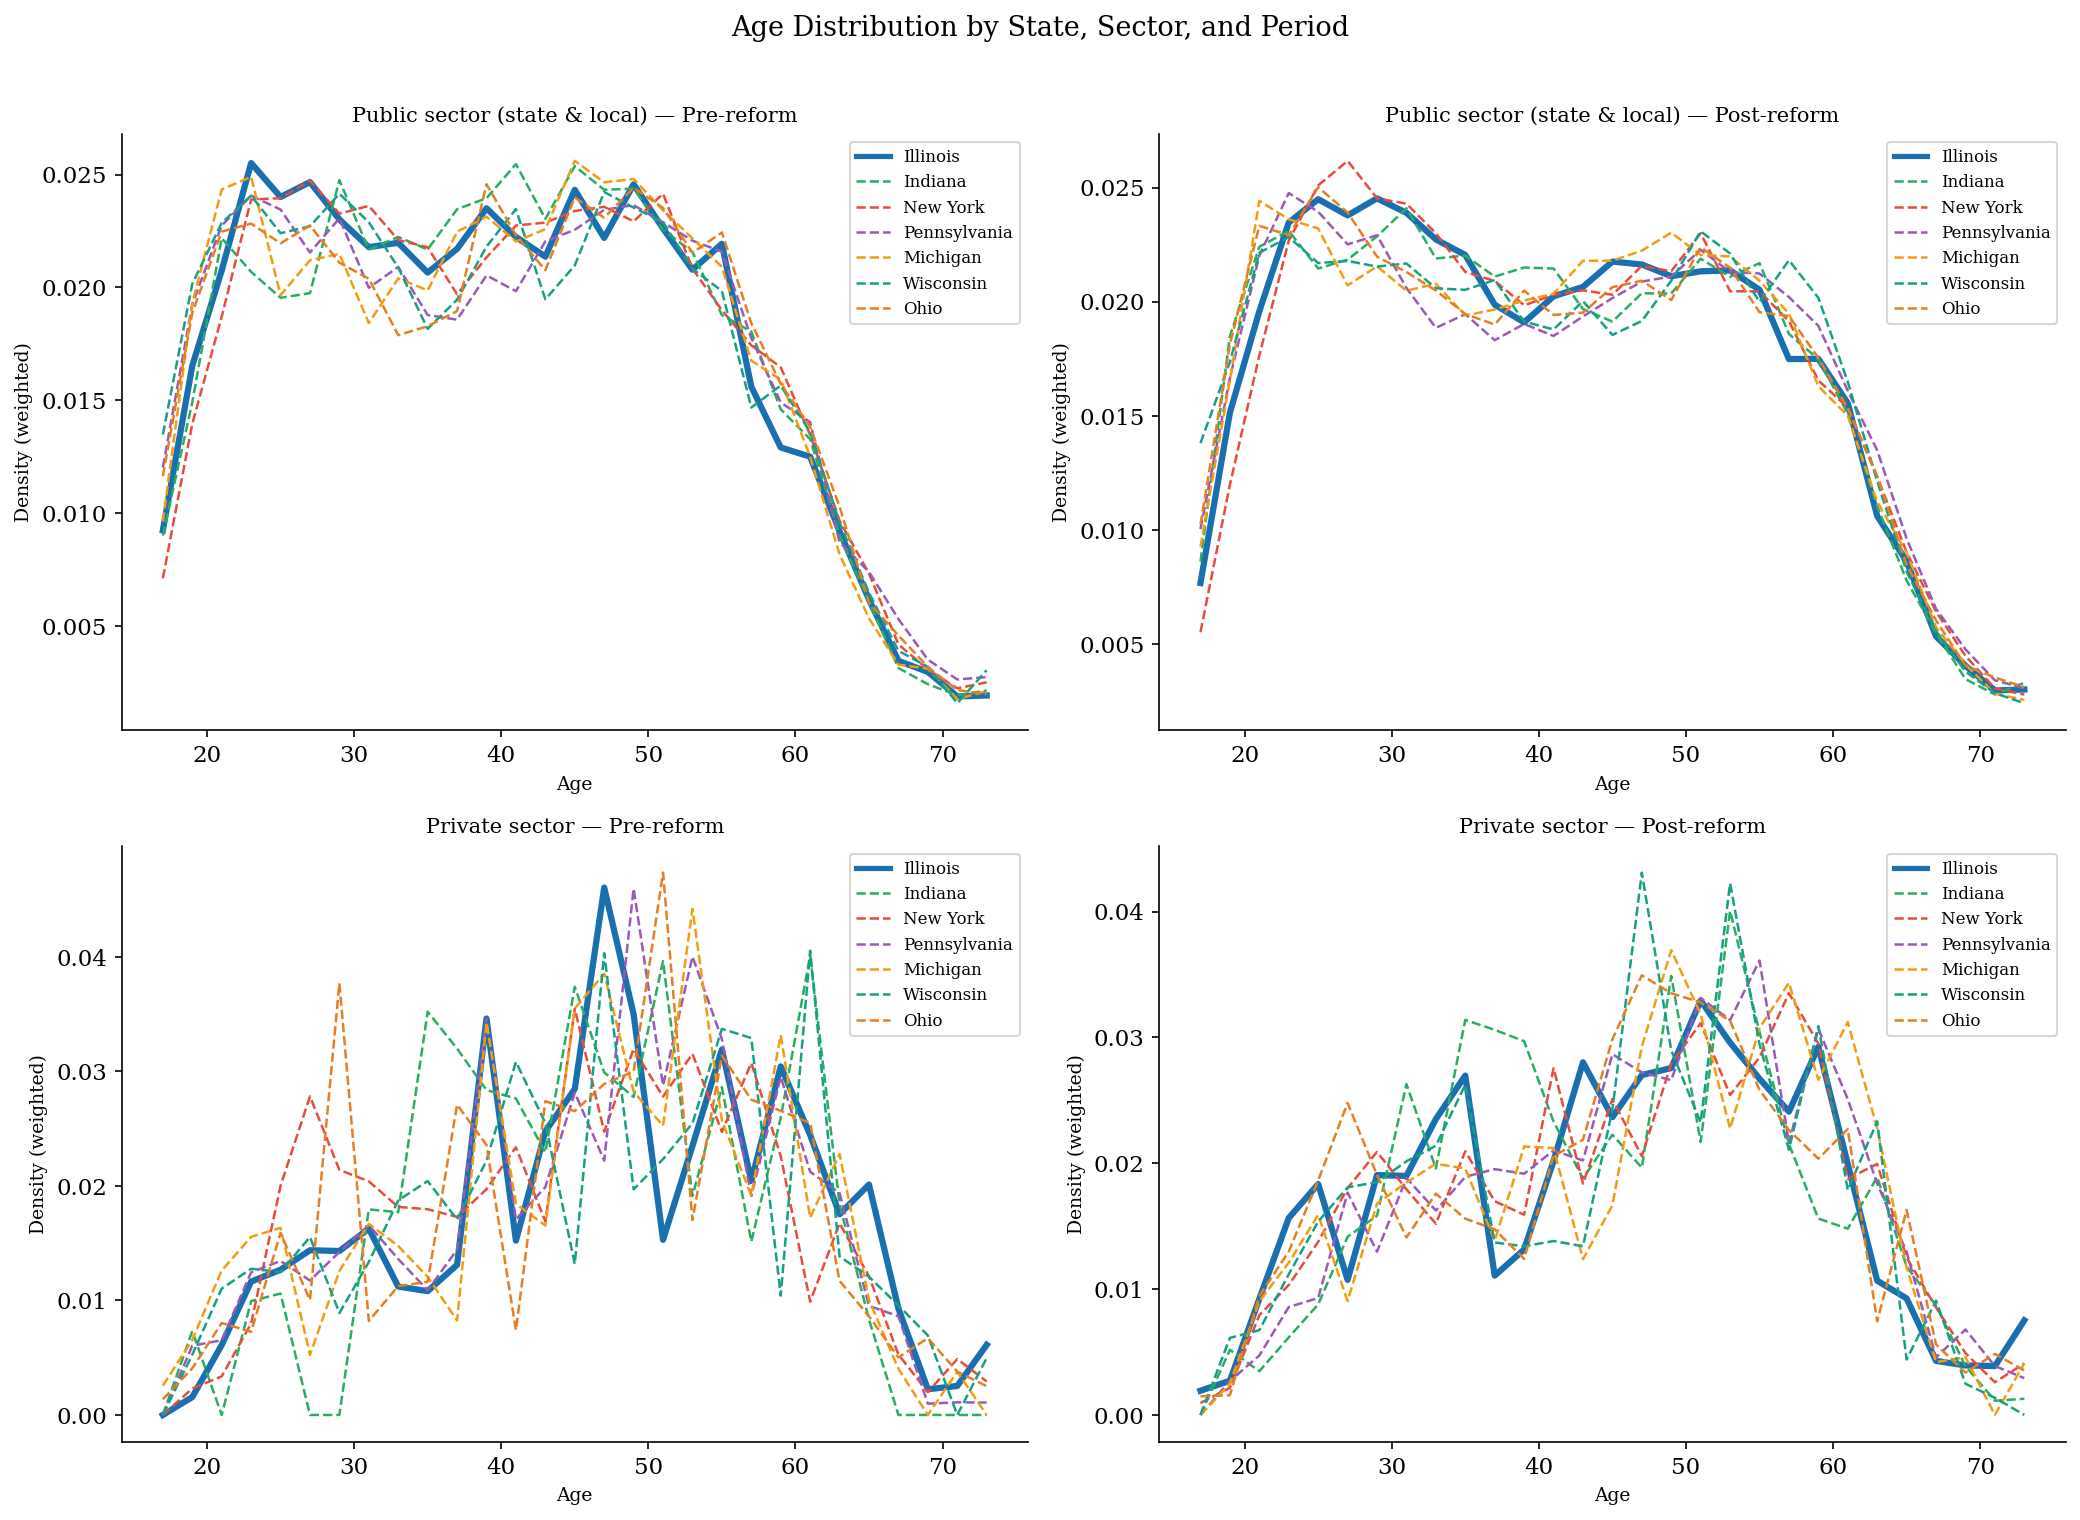

In [10]:
# ── FIGURE 1: Age distributions — public vs private, IL vs comparison ───────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

panels = [
    (axes[0,0], 'pub_sl',  'pre',  'Public sector (state & local) — Pre-reform'),
    (axes[0,1], 'pub_sl',  'post', 'Public sector (state & local) — Post-reform'),
    (axes[1,0], 'private', 'pre',  'Private sector — Pre-reform'),
    (axes[1,1], 'private', 'post', 'Private sector — Post-reform'),
]

for ax, sector_col, period, title in panels:
    period_mask = morg['post'] == (0 if period == 'pre' else 1)

    for fips in states:
        sub = morg[(morg['stfips']==fips) & (morg[sector_col]==1) & period_mask
                   & morg['age'].notna() & (morg['wt']>0)]
        if len(sub) < 50: continue

        bins   = np.arange(16, 75, 2)
        counts, edges = np.histogram(sub['age'], bins=bins, weights=sub['wt'], density=True)
        centres = (edges[:-1] + edges[1:]) / 2

        col_c = STATE_COLORS.get(fips, '#888')
        lw    = 2.5 if fips == 17 else 1.2
        ls    = '-'  if fips == 17 else '--'
        ax.plot(centres, counts, ls, color=col_c, lw=lw,
                label=STATES_OF_INTEREST.get(fips, str(fips)))

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Age', fontsize=9)
    ax.set_ylabel('Density (weighted)', fontsize=9)
    ax.legend(fontsize=8)

# IL highlight note
for ax in axes.flat:
    for line in ax.get_lines():
        if line.get_label() == 'Illinois':
            line.set_linewidth(3.0)
            break

plt.suptitle('Age Distribution by State, Sector, and Period', fontsize=13, y=1.01)
plt.tight_layout()
save(fig, 'fig1_age_distribution')
plt.show()


  Saved fig2_female_share


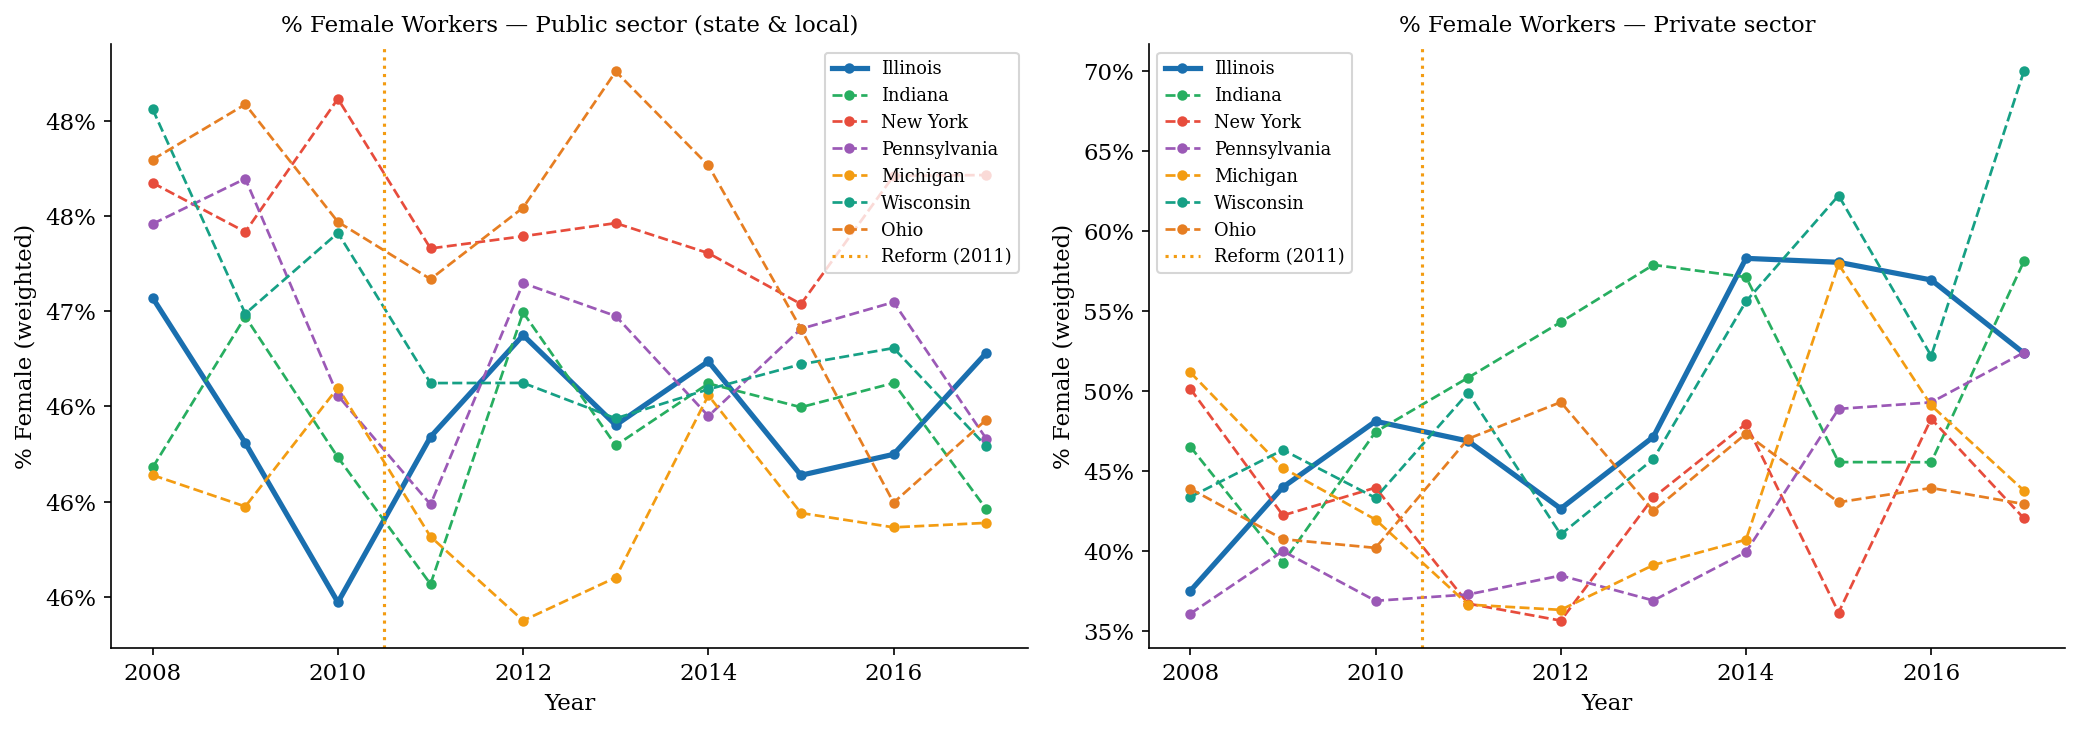

In [11]:
# ── FIGURE 2: Female share over time by state and sector ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sector_col, title in [
    (axes[0], 'pub_sl',  'Public sector (state & local)'),
    (axes[1], 'private', 'Private sector'),
]:
    for fips in states:
        records = []
        for yr in YEARS:
            sub = morg[(morg['stfips']==fips) & (morg[sector_col]==1)
                       & (morg['year']==yr) & (morg['wt']>0)]
            if len(sub) < 20: continue
            records.append({'year': yr, 'val': wpct(sub, 'female')})
        if not records: continue
        df_plot = pd.DataFrame(records)
        col_c = STATE_COLORS.get(fips, '#888')
        lw  = 2.5 if fips == 17 else 1.3
        ls  = '-'  if fips == 17 else '--'
        ax.plot(df_plot['year'], df_plot['val'], ls+'o', color=col_c, lw=lw,
                ms=4, label=STATES_OF_INTEREST.get(fips, str(fips)))

    ax.axvline(REFORM_YEAR - 0.5, color='#f39c12', lw=1.5, ls=':',
               label='Reform (2011)')
    ax.set_title(f'% Female Workers — {title}', fontsize=11)
    ax.set_xlabel('Year'); ax.set_ylabel('% Female (weighted)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.legend(fontsize=8.5)

plt.tight_layout()
save(fig, 'fig2_female_share')
plt.show()


  Saved fig3_earnings


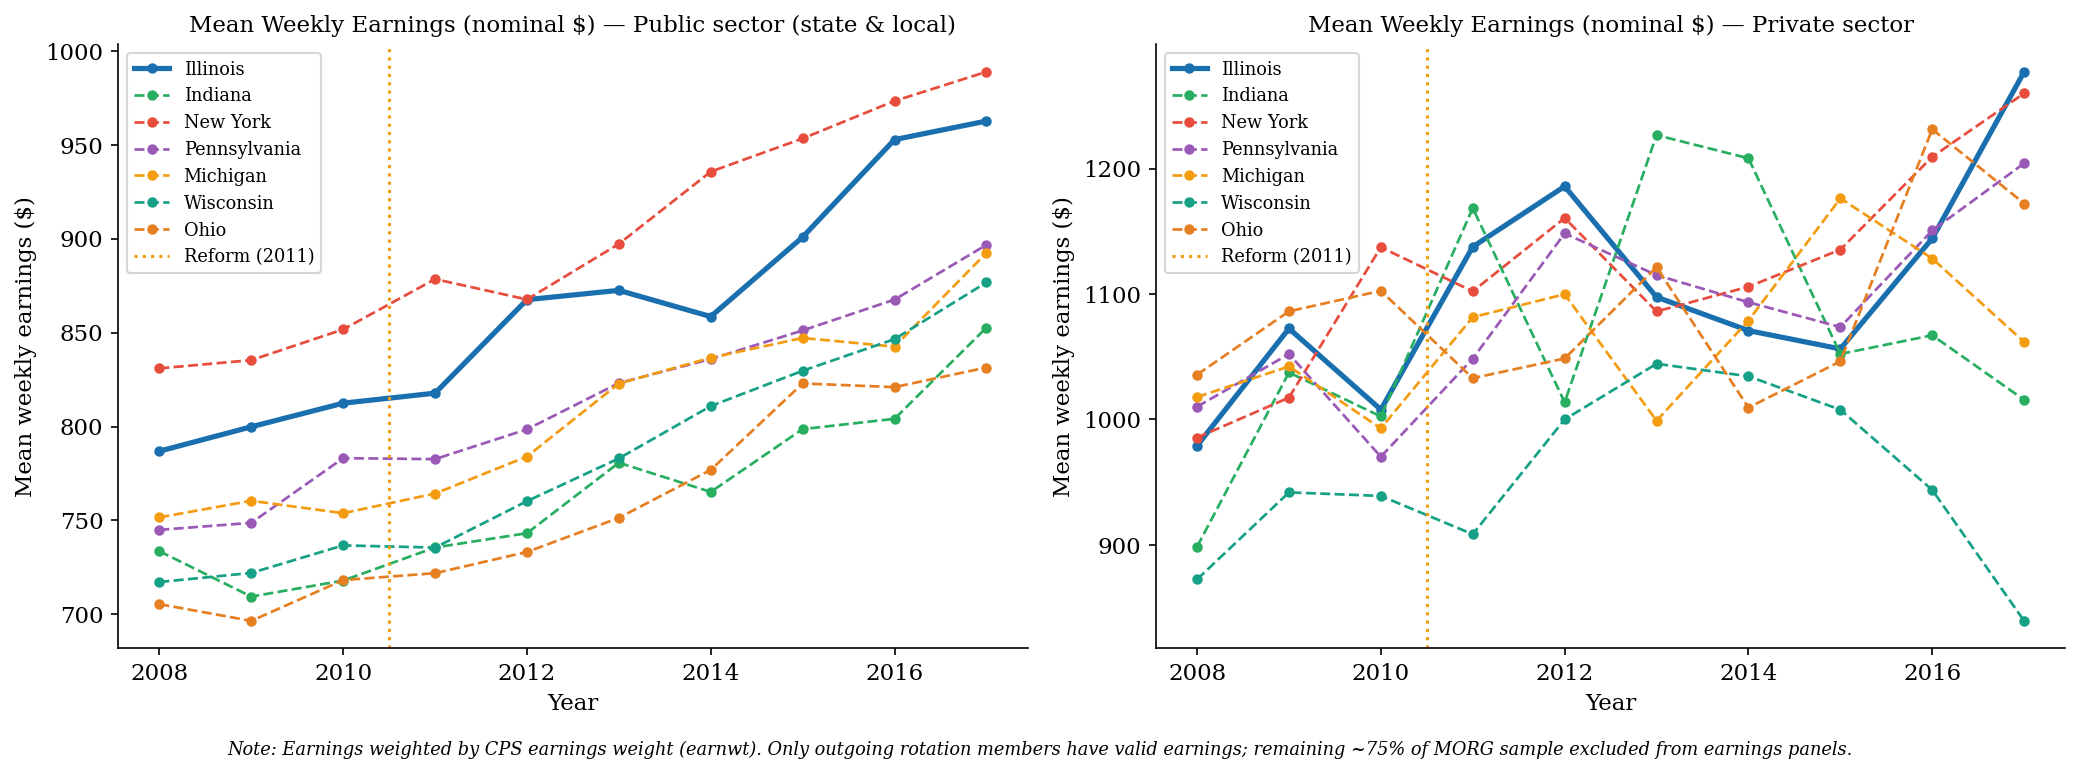

In [12]:
# ── FIGURE 3: Mean weekly earnings over time ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sector_col, title in [
    (axes[0], 'pub_sl',  'Public sector (state & local)'),
    (axes[1], 'private', 'Private sector'),
]:
    for fips in states:
        records = []
        for yr in YEARS:
            sub = morg[(morg['stfips']==fips) & (morg[sector_col]==1)
                       & (morg['year']==yr) & morg['earnwke'].notna()]
            if len(sub) < 20: continue
            records.append({'year': yr, 'val': wmean(sub, 'earnwke', 'earnwt')})
        if not records: continue
        df_plot = pd.DataFrame(records)
        col_c = STATE_COLORS.get(fips, '#888')
        lw  = 2.5 if fips == 17 else 1.3
        ls  = '-'  if fips == 17 else '--'
        ax.plot(df_plot['year'], df_plot['val'], ls+'o', color=col_c, lw=lw,
                ms=4, label=STATES_OF_INTEREST.get(fips, str(fips)))

    ax.axvline(REFORM_YEAR - 0.5, color='#f39c12', lw=1.5, ls=':',
               label='Reform (2011)')
    ax.set_title(f'Mean Weekly Earnings (nominal $) — {title}', fontsize=11)
    ax.set_xlabel('Year'); ax.set_ylabel('Mean weekly earnings ($)')
    ax.legend(fontsize=8.5)

fig.text(0.5, -0.02,
    'Note: Earnings weighted by CPS earnings weight (earnwt). '
    'Only outgoing rotation members have valid earnings; '
    'remaining ~75% of MORG sample excluded from earnings panels.',
    ha='center', fontsize=8.5, style='italic')
plt.tight_layout()
save(fig, 'fig3_earnings')
plt.show()


  Saved fig4_union_coverage


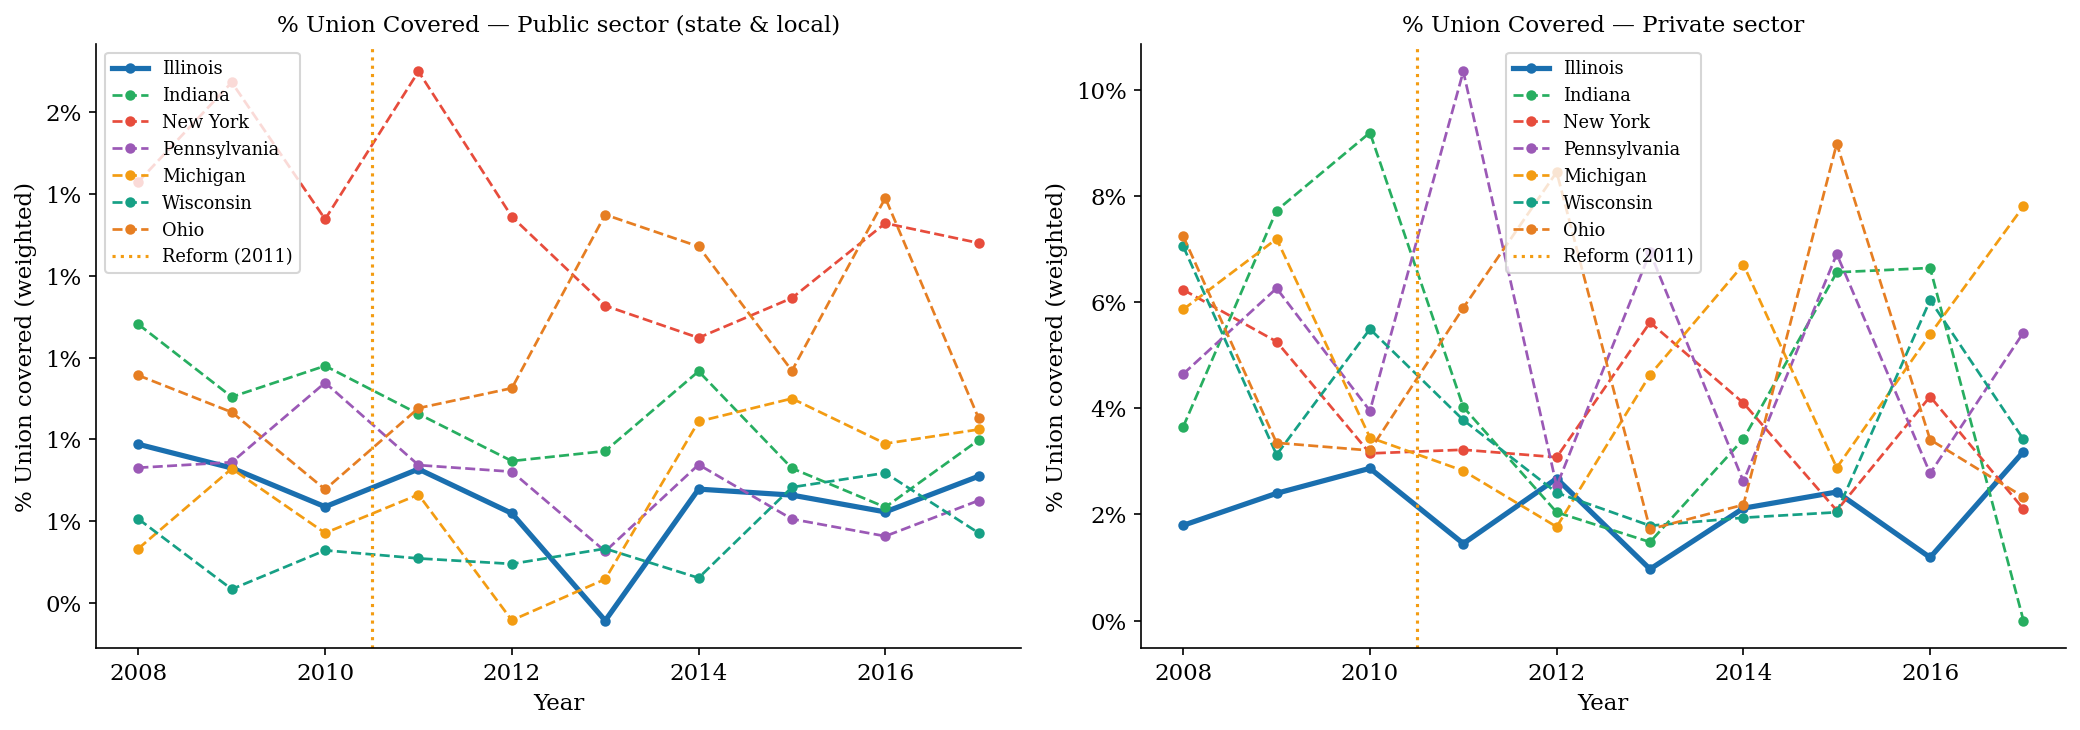

In [13]:
# ── FIGURE 4: Union coverage over time ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sector_col, title in [
    (axes[0], 'pub_sl',  'Public sector (state & local)'),
    (axes[1], 'private', 'Private sector'),
]:
    for fips in states:
        records = []
        for yr in YEARS:
            sub = morg[(morg['stfips']==fips) & (morg[sector_col]==1) & (morg['year']==yr)]
            if len(sub) < 20: continue
            records.append({'year': yr, 'val': wpct(sub, 'union_cov')})
        if not records: continue
        df_plot = pd.DataFrame(records)
        col_c = STATE_COLORS.get(fips, '#888')
        lw  = 2.5 if fips == 17 else 1.3
        ls  = '-'  if fips == 17 else '--'
        ax.plot(df_plot['year'], df_plot['val'], ls+'o', color=col_c, lw=lw,
                ms=4, label=STATES_OF_INTEREST.get(fips, str(fips)))

    ax.axvline(REFORM_YEAR - 0.5, color='#f39c12', lw=1.5, ls=':',
               label='Reform (2011)')
    ax.set_title(f'% Union Covered — {title}', fontsize=11)
    ax.set_xlabel('Year'); ax.set_ylabel('% Union covered (weighted)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.legend(fontsize=8.5)

plt.tight_layout()
save(fig, 'fig4_union_coverage')
plt.show()


  Saved fig5_education_composition


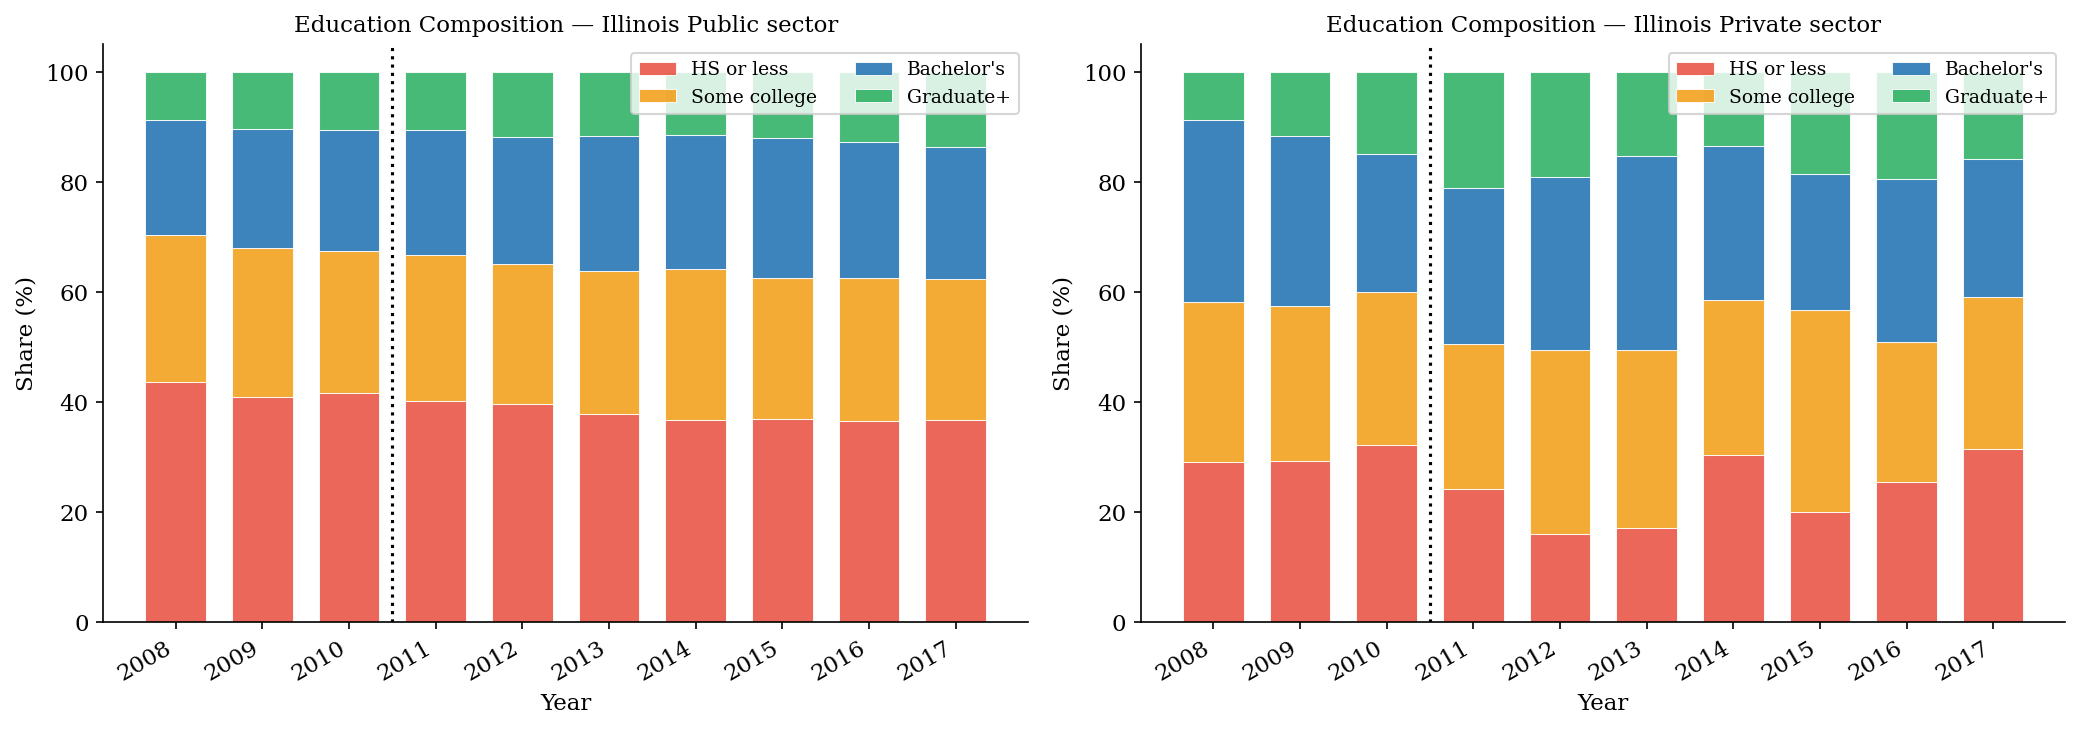

In [14]:
# ── FIGURE 5: Education composition over time — Illinois ─────────────────────
il_pub  = morg[(morg['stfips']==17) & (morg['pub_sl']==1)]
il_priv = morg[(morg['stfips']==17) & (morg['private']==1)]

educ_cols   = ['educ_hs_or_less','educ_some_college','educ_bachelor','educ_graduate']
educ_labels = ['HS or less','Some college',"Bachelor's",'Graduate+']
educ_colors = ['#e74c3c','#f39c12','#1a6faf','#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_grp, title in [(axes[0], il_pub, 'Public sector'), (axes[1], il_priv, 'Private sector')]:
    years_avail = sorted(df_grp['year'].unique())
    shares = {c: [] for c in educ_cols}
    for yr in years_avail:
        sub = df_grp[df_grp['year']==yr]
        tot = sum(wpct(sub, c) for c in educ_cols)
        for c in educ_cols:
            shares[c].append(wpct(sub, c) / tot * 100 if tot > 0 else 0)

    bottom = np.zeros(len(years_avail))
    for c, lbl, col_c in zip(educ_cols, educ_labels, educ_colors):
        vals = np.array(shares[c])
        ax.bar(years_avail, vals, bottom=bottom, label=lbl,
               color=col_c, alpha=0.85, width=0.7, edgecolor='white', lw=0.5)
        bottom += vals

    ax.axvline(REFORM_YEAR - 0.5, color='black', lw=1.5, ls=':')
    ax.set_title(f'Education Composition — Illinois {title}', fontsize=11)
    ax.set_xlabel('Year'); ax.set_ylabel('Share (%)')
    ax.set_xticks(years_avail)
    ax.set_xticklabels([str(y) for y in years_avail], rotation=30, ha='right')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9, loc='upper right', ncol=2)

plt.tight_layout()
save(fig, 'fig5_education_composition')
plt.show()


  Saved fig6_mean_age


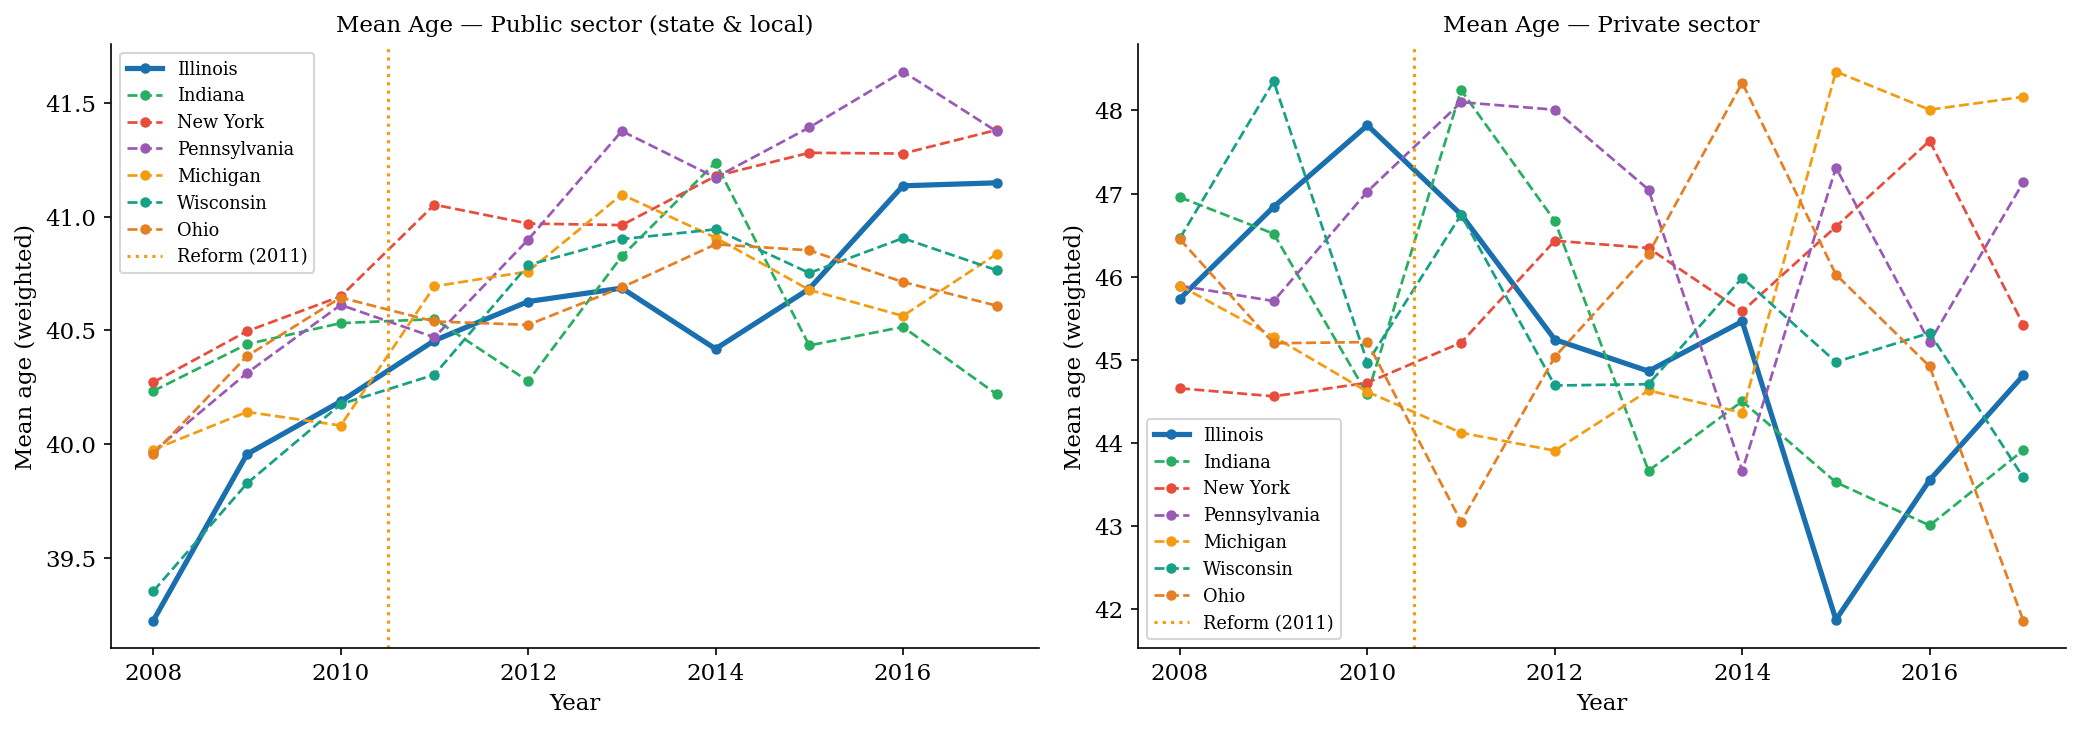

In [15]:
# ── FIGURE 6: Mean age over time by state — public vs private ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sector_col, title in [
    (axes[0], 'pub_sl',  'Public sector (state & local)'),
    (axes[1], 'private', 'Private sector'),
]:
    for fips in states:
        records = []
        for yr in YEARS:
            sub = morg[(morg['stfips']==fips) & (morg[sector_col]==1)
                       & (morg['year']==yr) & morg['age'].notna()]
            if len(sub) < 20: continue
            records.append({'year': yr, 'val': wmean(sub, 'age')})
        if not records: continue
        df_plot = pd.DataFrame(records)
        col_c = STATE_COLORS.get(fips, '#888')
        lw  = 2.5 if fips == 17 else 1.3
        ls  = '-'  if fips == 17 else '--'
        ax.plot(df_plot['year'], df_plot['val'], ls+'o', color=col_c, lw=lw,
                ms=4, label=STATES_OF_INTEREST.get(fips, str(fips)))

    ax.axvline(REFORM_YEAR - 0.5, color='#f39c12', lw=1.5, ls=':',
               label='Reform (2011)')
    ax.set_title(f'Mean Age — {title}', fontsize=11)
    ax.set_xlabel('Year'); ax.set_ylabel('Mean age (weighted)')
    ax.legend(fontsize=8.5)

plt.tight_layout()
save(fig, 'fig6_mean_age')
plt.show()


  Saved fig7_race_composition


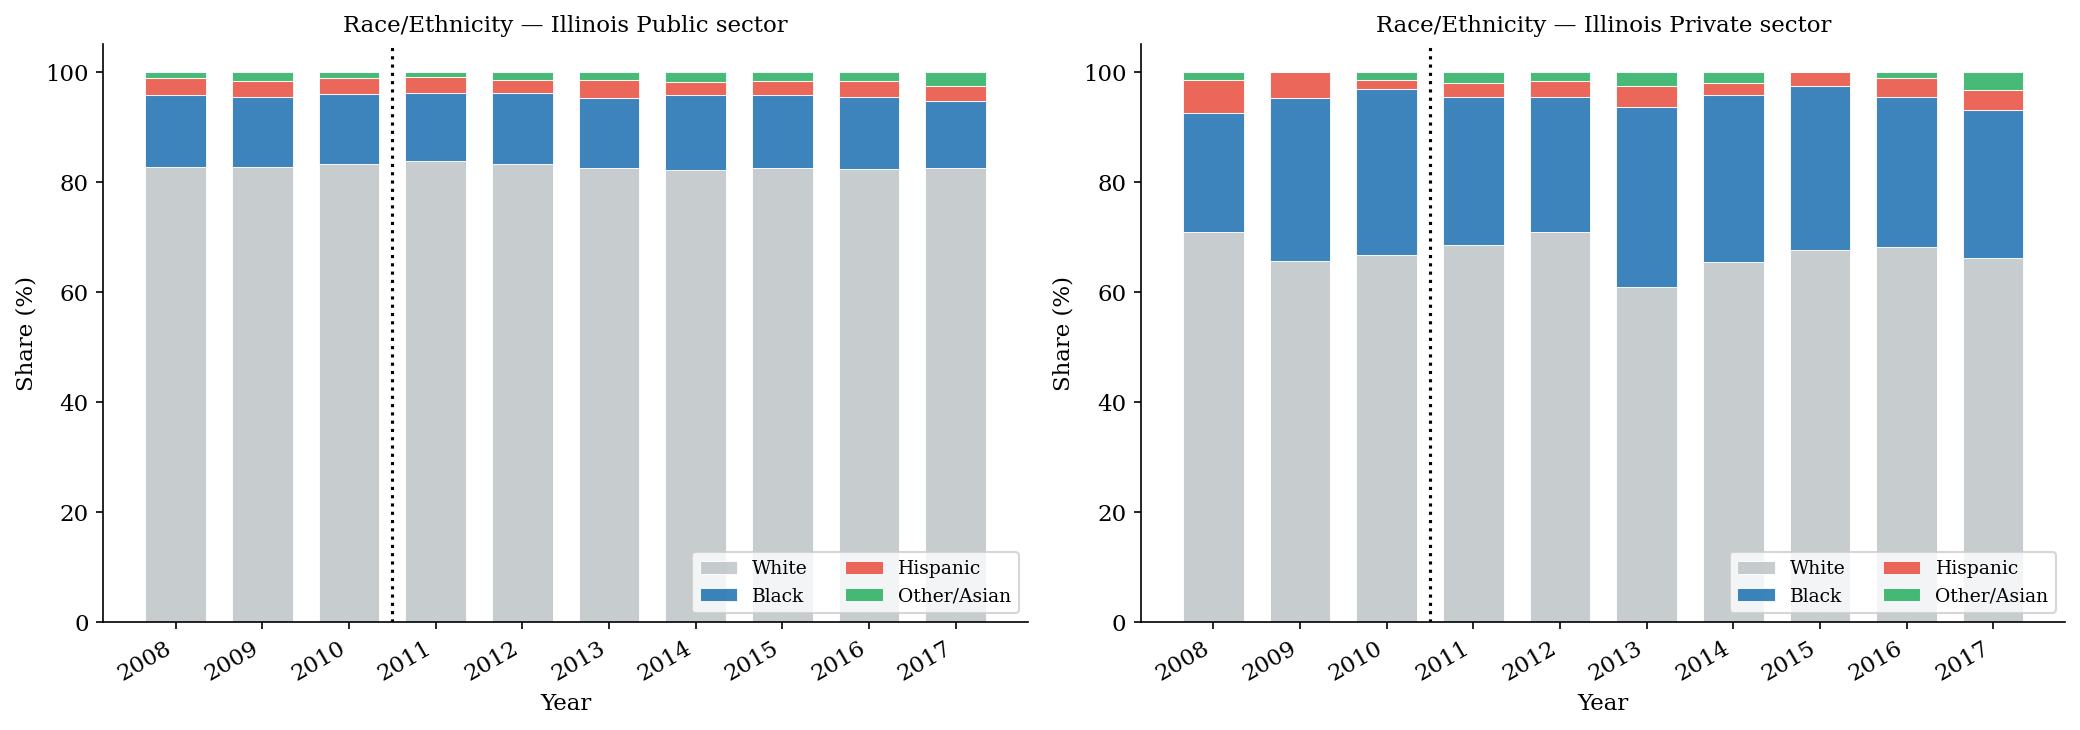

In [16]:
# ── FIGURE 7: Race/ethnicity composition — IL public vs private ───────────────
# Note: pre-2003 MORG race coding has 3 categories (White/Black/Other)
# 'asian' is not separately identified; collapsed into 'other_race'
race_cols   = ['white','black','is_hispanic','other_race']
race_labels = ['White','Black','Hispanic','Other/Asian']
race_colors = ['#bdc3c7','#1a6faf','#e74c3c','#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sector_col, title in [
    (axes[0], 'pub_sl',  'Public sector'),
    (axes[1], 'private', 'Private sector'),
]:
    il_sub  = morg[(morg['stfips']==17) & (morg[sector_col]==1)]
    years_a = sorted(il_sub['year'].unique())
    shares = {c: [] for c in race_cols}
    for yr in years_a:
        sub = il_sub[il_sub['year']==yr]
        tot = sum(wpct(sub, c) for c in race_cols)
        for c in race_cols:
            shares[c].append(wpct(sub, c) / tot * 100 if tot > 0 else 0)

    bottom = np.zeros(len(years_a))
    for c, lbl, col_c in zip(race_cols, race_labels, race_colors):
        vals = np.array(shares[c])
        ax.bar(years_a, vals, bottom=bottom, label=lbl,
               color=col_c, alpha=0.85, width=0.7, edgecolor='white', lw=0.5)
        bottom += vals

    ax.axvline(REFORM_YEAR - 0.5, color='black', lw=1.5, ls=':')
    ax.set_title(f'Race/Ethnicity — Illinois {title}', fontsize=11)
    ax.set_xlabel('Year'); ax.set_ylabel('Share (%)')
    ax.set_xticks(years_a)
    ax.set_xticklabels([str(y) for y in years_a], rotation=30, ha='right')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9, loc='lower right', ncol=2)

plt.tight_layout()
save(fig, 'fig7_race_composition')
plt.show()


  Saved fig8_public_employment_share


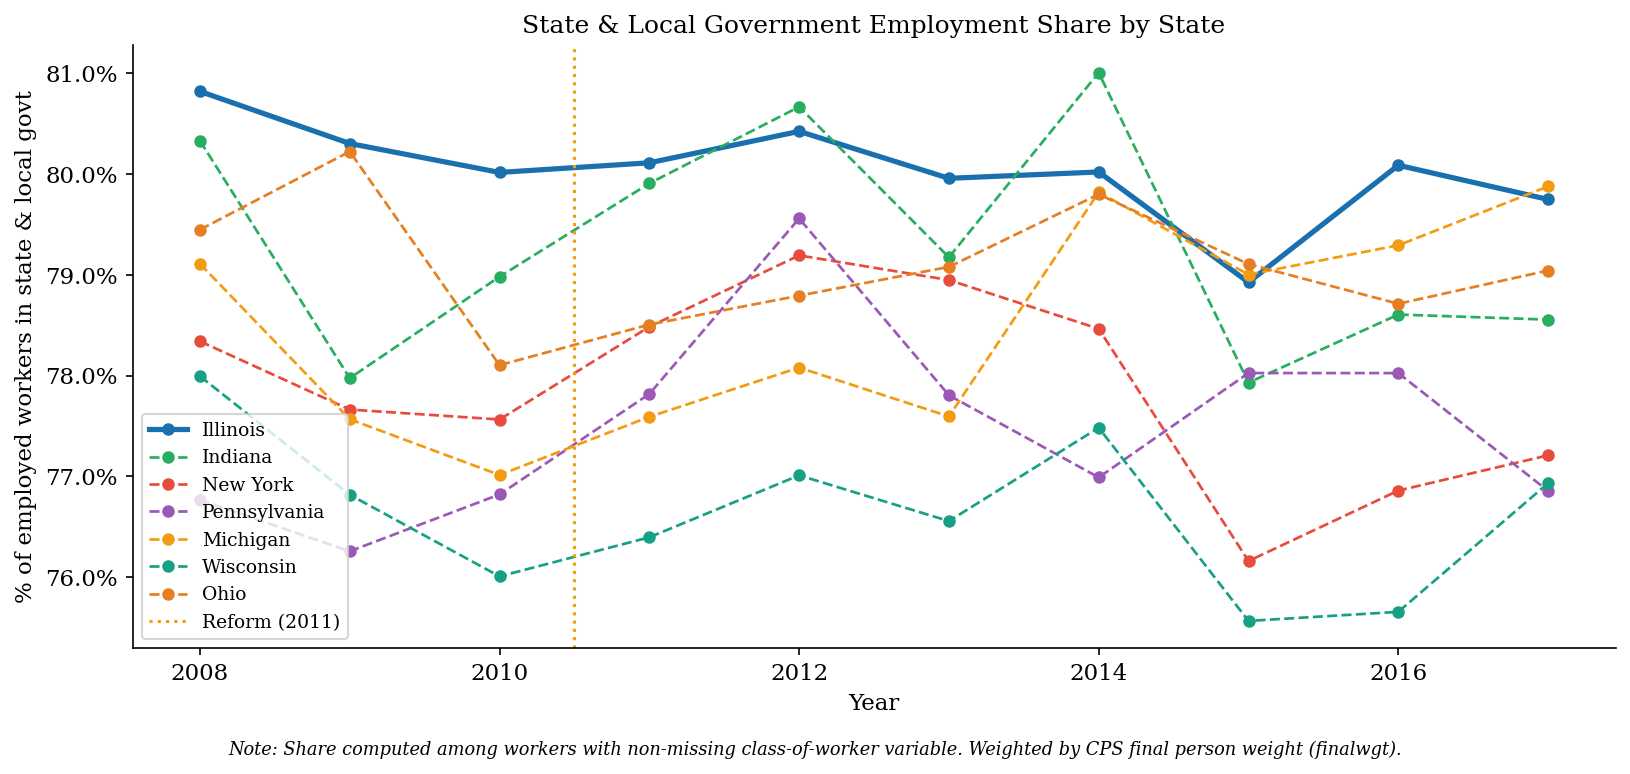

In [17]:
# ── FIGURE 8: Public-sector employment share over time by state ──────────────
fig, ax = plt.subplots(figsize=(11, 5))

for fips in states:
    records = []
    for yr in YEARS:
        sub = morg[(morg['stfips']==fips) & (morg['year']==yr)
                   & morg['class94_raw'].notna() & (morg['class94_raw'] > 0)]
        if len(sub) < 50: continue
        pub_wt  = sub[sub['pub_sl']==1]['wt'].sum()
        tot_wt  = sub['wt'].sum()
        records.append({'year': yr, 'val': pub_wt / tot_wt * 100 if tot_wt > 0 else np.nan})
    if not records: continue
    df_plot = pd.DataFrame(records)
    col_c = STATE_COLORS.get(fips, '#888')
    lw  = 2.5 if fips == 17 else 1.3
    ls  = '-'  if fips == 17 else '--'
    ax.plot(df_plot['year'], df_plot['val'], ls+'o', color=col_c, lw=lw,
            ms=5, label=STATES_OF_INTEREST.get(fips, str(fips)))

ax.axvline(REFORM_YEAR - 0.5, color='#f39c12', lw=1.5, ls=':',
           label='Reform (2011)')
ax.set_title('State & Local Government Employment Share by State', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('% of employed workers in state & local govt')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=9)

fig.text(0.5, -0.02,
    'Note: Share computed among workers with non-missing class-of-worker variable. '
    'Weighted by CPS final person weight (finalwgt).',
    ha='center', fontsize=8.5, style='italic')
plt.tight_layout()
save(fig, 'fig8_public_employment_share')
plt.show()


## Output files

All saved to `morg_descriptive_output/`:

| File | Content |
|------|---------|
| `table1a_preperiod_pubsector.csv` | Pre-reform public sector characteristics by state |
| `table1b_preperiod_private.csv` | Pre-reform private sector characteristics by state |
| `table1c_postperiod_pubsector.csv` | Post-reform public sector characteristics by state |
| `table2_illinois_prepost.csv` | Illinois pre vs post, public vs private |
| `table_summary_latex.tex` | LaTeX-ready summary table |
| `fig1_age_distribution` | Age density: public vs private × pre vs post |
| `fig2_female_share` | % Female over time by state and sector |
| `fig3_earnings` | Mean weekly earnings over time |
| `fig4_union_coverage` | Union coverage over time |
| `fig5_education_composition` | Education stacked bar (Illinois) |
| `fig6_mean_age` | Mean age over time by state |
| `fig7_race_composition` | Race/ethnicity composition (Illinois) |
| `fig8_public_employment_share` | Public-sector employment share by state |

**Note on earnings:** Only CPS outgoing rotation members (~25% of the full MORG sample per year)
have valid earnings data. All earnings statistics use `earnwt`; all other statistics use `finalwgt`.
